# Ejercicio Integrador — Rating, Sentimiento y Perfil de Viajero
 
Una cadena de hoteles quiere entender qué hace que una estadía sea buena o mala, más allá del promedio de estrellas. Tienen 340 reseñas de sus hoteles, con el texto completo de cada reseña y datos de quién la escribió. Se pide un análisis que combine el rating, el texto y el perfil del viajero para producir conclusiones accionables.
 
## Dataset
 
`reviews_hoteles.csv` — 340 filas, 8 columnas:
 
| Columna | Descripción |
|---|---|
| `fecha` | Fecha de la reseña |
| `hotel` | Nombre del hotel |
| `ciudad` | Ciudad donde está el hotel |
| `categoria_hotel` | Categoría oficial del hotel, en estrellas (1 a 5, fija por hotel) |
| `rating_usuario` | Puntuación que el huésped le dio a su estadía (1 a 5) |
| `review` | Texto de la reseña |
| `motivo_viaje` | Negocios, Familia, Pareja, Amigos o Solo |
| `procedencia` | País de origen del huésped |

## Consigna
 
1. **EDA sobre rating.** Explorar la distribución de `rating_usuario` y compararla contra `categoria_hotel`. ¿Los hoteles de más estrellas tienen, en promedio, mejor rating de usuario?

In [4]:
"""PREPARATIVOS"""
import pandas as pd
from pysentimiento import create_analyzer 
df = pd.read_csv("reviews_hoteles.csv")

In [5]:
# Tu codigo acá

2. **Análisis de sentimiento.** Usar una herramienta de NLP ya entrenada para español (no entrenar ningún modelo propio) para clasificar cada `review` como positiva, negativa o neutra.

In [ ]:
analyzer = create_analyzer(task="sentiment", lang="es")

def textualizar ():
    list_of_tuples = list(df[["review"]].itertuples(index=False, name=None))#metodo pandas para pasar a tuplas 
    #https://www.slingacademy.com/article/pandas-converting-a-dataframe-to-a-list-of-tuples/
    # print(list_of_tuples)
    return list_of_tuples

reviews = textualizar()
resultados = pd.Series(reviews).apply(lambda review: analyzer.predict(review[0]))
print(resultados)

#hacer eso costo asi que voy a dejar mi guia de porque hice cada cosa
"""
1 = defini una funcion que pasa a una lista de tuplas individuales las reseñas del df

    [
        ("La comida estuvo excelente",),
        ("No me gustó para nada",),
        ("Muy buen servicio",)
    ] notar que cada una es individual de la otra (las , despues de los parentesis)
      como si fuera un diccionario



2 = luego con pd.Series, pase esas tuplas individuales a una serie sucesiva de strings

    0    ("La comida estuvo excelente",)
    1    ("No me gustó para nada",)
    2    ("Muy buen servicio",)
    notar que cada cadena de strings sucede a la otra (notar que solo hay comas luego de las comillas)
    ahora esto se parece mas a un vector 


3 = .apply(lambda review: ...) significa "agarra cada review de esa serie y hace esto
    lambda es una forma corta de crear funciones anonimas, de una o pocas instrucciones
    en resumen, esa funcion lambda llama al analyzer y le inyecta la primer review [0]
"""

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9492.15it/s]


0      AnalyzerOutput(output=NEU, probas={NEU: 0.800,...
1      AnalyzerOutput(output=POS, probas={POS: 0.979,...
2      AnalyzerOutput(output=NEG, probas={NEG: 0.906,...
3      AnalyzerOutput(output=NEG, probas={NEG: 0.906,...
4      AnalyzerOutput(output=POS, probas={POS: 0.953,...
                             ...                        
335    AnalyzerOutput(output=POS, probas={POS: 0.953,...
336    AnalyzerOutput(output=POS, probas={POS: 0.977,...
337    AnalyzerOutput(output=NEG, probas={NEG: 0.906,...
338    AnalyzerOutput(output=POS, probas={POS: 0.979,...
339    AnalyzerOutput(output=POS, probas={POS: 0.953,...
Length: 340, dtype: object


3. **Rating vs. sentimiento.** Convertir `rating_usuario` a una categoría comparable con el sentimiento detectado, y encontrar los casos donde no coinciden. Calcular qué porcentaje de las reseñas cae en cada caso.

In [7]:
# Tu codigo acá

4. **Segmentación por perfil.** Comparar rating y sentimiento según `motivo_viaje` y `procedencia`. ¿Hay diferencias entre cómo puntúan los viajeros de negocios y los de ocio?

KeyError: 'produccion'

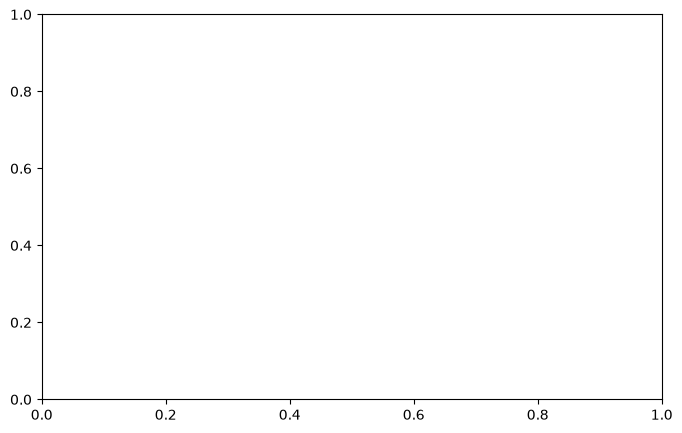

5. **Brecha categoría-experiencia.** Por hotel, calcular la diferencia entre `categoria_hotel` y el `rating_usuario` promedio. Identificar los hoteles con mayor brecha negativa.

In [9]:
# Tu codigo acá

6. **Visualización.** Al menos dos gráficos: uno que cruce rating y sentimiento, y otro que compare sentimiento entre segmentos de viajero.

In [10]:
# Tu codigo acá

7. **Storytelling.** Con los resultados anteriores, escribir una conclusión de negocio de 3 a 5 oraciones dirigida a la cadena de hoteles. Debe basarse en los números encontrados, no en impresiones generales.

In [11]:
# Tu codigo acá

## Pistas
 
- Para el análisis de sentimiento, `pysentimiento` es una librería en Python con un modelo ya entrenado para español — no hace falta entrenar nada, se instala y se usa directo.
- `categoria_hotel` y `rating_usuario` son cosas distintas: una es fija por hotel, la otra varía por reseña. La consigna 5 depende de no confundirlas.
- Para "no coincide" en la consigna 3, primero hay que llevar el rating a la misma escala que devuelve el modelo de sentimiento (positivo / negativo / neutro).
- Conviene resolver la consigna 1 antes que la 2 — tener una idea de cómo se distribuye el rating ayuda a interpretar mejor los resultados del sentimiento después.